# Pipeline de Treinamento — Previsão de `geek_rating` (BoardGameGeek)

Este notebook treina e compara 4 modelos para prever o **geek_rating** (Bayesian rating do BGG) a partir da base já tratada em `tratamento_dados.ipynb`:

## 1. Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import shap

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

N_OUTER = 5   # folds da validação cruzada externa (estimativa de generalização)
N_INNER = 3   # folds da validação cruzada interna (escolha de hiperparâmetros)
N_ITER = 20   # nº de combinações de hiperparâmetros amostradas (RandomizedSearchCV / ParameterSampler)

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento dos dados

Carregamos `bgg_dataset_tratado.csv`, gerado pelo notebook `tratamento_dados.ipynb`. A base já está limpa, sem valores nulos, com variáveis categóricas codificadas (one-hot para categorias/mecânicas), publisher e descrição vetorizados. O `geek_rating` (nosso target) permanece na escala original.

In [2]:
df = pd.read_csv("../data/bgg_dataset_tratado.csv")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Valores nulos totais: {df.isna().sum().sum()}")
df.head()

Shape: 8,210 linhas x 159 colunas
Valores nulos totais: 0


,geek_rating,complexity,min_players,max_players,min_time,max_time,min_suggested_age,publisher_freq,min_time_was_missing,max_time_was_missing,min_suggested_age_was_missing,cat_Abstract Strategy,cat_Action,cat_Adventure,cat_Ancient,cat_Animals,cat_Bluffing,cat_Card Game,cat_Children's Game,cat_City Building,cat_Civilization,cat_Deduction,cat_Dexterity,cat_Dice,cat_Economic,...,desc_topic_28,desc_topic_29,desc_topic_30,desc_topic_31,desc_topic_32,desc_topic_33,desc_topic_34,desc_topic_35,desc_topic_36,desc_topic_37,desc_topic_38,desc_topic_39,desc_topic_40,desc_topic_41,desc_topic_42,desc_topic_43,desc_topic_44,desc_topic_45,desc_topic_46,desc_topic_47,desc_topic_48,desc_topic_49,desc_topic_50,desc_topic_51,desc_topic_52
0,8.394,3.86,2,4,60,120,14,0.001434,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,-0.058433,0.009345,0.016651,0.015986,0.025000,-0.030609,-0.081961,-0.016744,-0.009982,0.004833,-0.023359,-0.006700,0.052733,0.025746,0.019850,0.026079,0.043745,-0.015449,-0.025951,0.014756,-0.005542,0.034305,-0.014527,-0.028504,-0.014838
1,8.354,3.80,1,4,90,150,14,0.000717,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,...,-0.007228,-0.000323,-0.007158,-0.014286,-0.005762,-0.007796,-0.012167,0.005890,-0.002589,0.013608,-0.003286,0.005077,0.024767,0.003011,0.009170,-0.000891,0.028214,0.000953,-0.008084,-0.011957,-0.000410,0.005482,0.013064,0.002398,0.009475
2,8.345,2.83,2,4,60,60,13,0.003824,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.030072,0.105894,0.147805,0.062949,0.016788,-0.083384,-0.083061,-0.055188,-0.073196,-0.014462,0.041995,0.020503,0.101092,0.024867,0.029581,0.060664,0.013352,0.010287,0.040223,-0.192117,0.088284,-0.062375,-0.111520,0.004890,-0.002578
3,8.296,3.92,1,4,60,120,14,0.000598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,-0.004115,0.032672,-0.024888,-0.011800,0.042112,-0.024433,0.000060,-0.021509,0.040342,0.009034,-0.046759,-0.015859,-0.075984,0.045251,0.013637,-0.143884,-0.033575,0.044223,0.049792,0.067953,0.152963,-0.082917,0.082087,-0.026368,0.016273
4,8.244,3.52,1,6,60,120,13,0.000478,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.002094,0.096413,0.017487,-0.033244,-0.074337,-0.002380,-0.047295,0.040982,-0.031296,-0.030977,0.010333,0.041498,0.029307,0.211799,0.005364,0.071105,-0.161384,-0.049646,0.021953,0.022739,-0.021775,-0.023202,0.085675,-0.043328,-0.076606


In [3]:
df["geek_rating"].describe()

count    8210.000000
mean        5.814454
std         0.480885
min         5.268000
25%         5.520000
50%         5.592000
75%         5.898000
max         8.394000
Name: geek_rating, dtype: float64

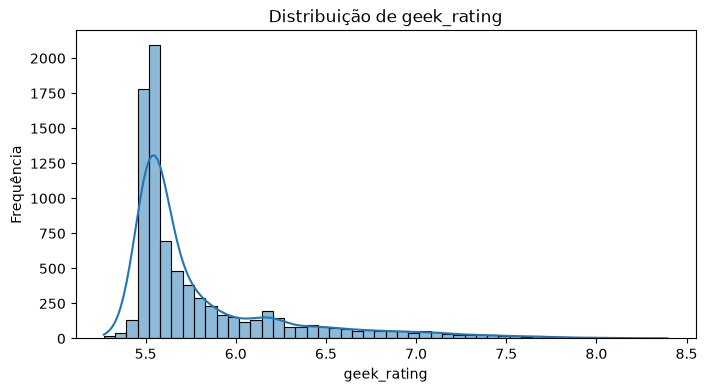

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["geek_rating"], bins=50, kde=True)
plt.title("Distribuição de geek_rating")
plt.xlabel("geek_rating")
plt.ylabel("Frequência")
plt.show()

**Observação importante sobre a distribuição:** o `geek_rating` é fortemente assimétrico à direita. A maioria dos jogos se concentra perto do "piso" do Bayesian average do BGG (em torno de 5.5), e poucos jogos atingem ratings altos (>7.5).

Essa assimetria é justamente o motivo pelo qual usamos `KFold(shuffle=True, random_state=RANDOM_STATE)` em todos os splits de validação cruzada deste notebook: sem embaralhar, um `KFold` simples percorre os dados na ordem em que estão no arquivo, o que pode concentrar os poucos jogos de rating alto em apenas um ou dois folds — fazendo com que alguns folds de treino/validação nunca vejam exemplos representativos da cauda direita da distribuição. Isso afeta diretamente a versão de classificação (Regressão Logística): as faixas mais altas terão poucas amostras, o que é esperado e será discutido nos resultados.

## 3. Separação de features e target

- `X`: todas as colunas exceto `geek_rating`.
- `y_reg`: o `geek_rating` contínuo (usado em Regressão Linear, Random Forest e Gradient Boosting).
- O target de classificação (`y_clf`) será derivado de `y_reg` *depois* do split treino/teste, para não vazar informação do teste na definição das faixas (usado apenas na Regressão Logística, seção 11).

In [5]:
X = df.drop(columns=["geek_rating"])
y_reg = df["geek_rating"]

print(f"X: {X.shape}")
print(f"y_reg: {y_reg.shape}")

X: (8210, 158)
y_reg: (8210,)


## 4. Holdout de teste final

Separamos uma fração dos dados (20%) como **holdout de teste**, que só é usado uma vez, no fim, para avaliar o modelo final de cada algoritmo (seção 8). Esse split usa `shuffle=True` (padrão do `train_test_split`) — importante pela mesma razão explicada na seção 2: a variável é assimétrica, então precisamos garantir que treino e teste tenham representação proporcional de toda a faixa de `geek_rating`.

O conjunto `X_train_full` / `y_train_full_reg` (80% restante) é o que entra no **Nested Cross-Validation** da seção 7: dentro dele, a validação cruzada externa cria seus próprios folds de "treino interno" e "validação", então não precisamos (e não devemos) separar um conjunto de validação fixo aqui — isso é exatamente o problema do item 2 da lista de correções (tuning com um único conjunto de validação) que estamos eliminando.

In [6]:
X_train_full, X_test, y_train_full_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino+Validação (usado no Nested CV): {X_train_full.shape[0]:,} amostras")
print(f"Teste (holdout final):                  {X_test.shape[0]:,} amostras")

Treino+Validação (usado no Nested CV): 6,568 amostras
Teste (holdout final):                  1,642 amostras


## 5. Baseline

Antes de qualquer modelo "de verdade", estabelecemos um **baseline** ingênuo: prever sempre a média do `geek_rating` do conjunto de treino. Qualquer modelo que não supere esse baseline com folga não está agregando valor real. O `DummyRegressor(strategy="mean")` não usa nenhuma feature de `X` — serve só como piso de comparação.

In [7]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_full, y_train_full_reg)
y_pred_baseline = baseline.predict(X_test)

rmse_baseline = mean_squared_error(y_test_reg, y_pred_baseline) ** 0.5
mae_baseline = mean_absolute_error(y_test_reg, y_pred_baseline)
r2_baseline = r2_score(y_test_reg, y_pred_baseline)

resultado_baseline = {"modelo": "Baseline (média)", "RMSE": rmse_baseline, "MAE": mae_baseline, "R2": r2_baseline}

print("--- Baseline (prevê sempre a média do treino) ---")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}  (por definição, R² do baseline-média é ~0 no próprio treino; no teste pode ser levemente negativo)")

--- Baseline (prevê sempre a média do treino) ---
RMSE: 0.4899
MAE:  0.3551
R²:   -0.0008  (por definição, R² do baseline-média é ~0 no próprio treino; no teste pode ser levemente negativo)


## 6. Função auxiliar de avaliação (regressão)

Função utilitária para reportar RMSE, MAE e R² de forma consistente entre os modelos.

In [8]:
def avaliar_regressao(nome_modelo, modelo, X_eval, y_eval):
    y_pred = modelo.predict(X_eval)
    rmse = mean_squared_error(y_eval, y_pred) ** 0.5
    mae = mean_absolute_error(y_eval, y_pred)
    r2 = r2_score(y_eval, y_pred)

    print(f"--- {nome_modelo} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {"modelo": nome_modelo, "RMSE": rmse, "MAE": mae, "R2": r2}

## 7. Nested Cross-Validation — função genérica

Esta é a peça central da reformulação. Para cada modelo, fazemos:

1. **Loop externo** (`outer_cv`, `N_OUTER` folds, `shuffle=True`): divide `X_train_full` em treino-interno / validação-externa. A métrica calculada na validação-externa de cada fold é a nossa estimativa **honesta** de erro de generalização, porque o fold de validação-externa nunca participa da escolha de hiperparâmetros.
2. **Loop interno** (`inner_cv`, `N_INNER` folds, `shuffle=True`), dentro de cada fold externo: usamos `RandomizedSearchCV` (que internamente usa `ParameterSampler` para sortear `N_ITER` combinações do espaço de hiperparâmetros) com `scoring="r2"` para escolher os melhores hiperparâmetros **usando apenas o treino-interno desse fold**.
3. O melhor estimador da busca interna é então avaliado no fold de validação-externa (dados nunca vistos pela busca de hiperparâmetros).

Ao final, temos `N_OUTER` valores de R² (e RMSE/MAE) — reportamos a **média ± desvio padrão**, que é uma estimativa muito mais confiável do desempenho esperado em dados novos do que um único número de um único split de validação.

> Note a diferença para o fluxo antigo (treino → validação → teste): ali, o mesmo conjunto de validação era usado repetidamente para escolher hiperparâmetros, o que tende a gerar uma estimativa **otimista** (overfitting nos hiperparâmetros em relação àquele conjunto específico). O Nested CV resolve isso ao nunca deixar o conjunto de avaliação tocar a escolha de hiperparâmetros.

In [9]:
def nested_cv_regressao(nome_modelo, pipeline, param_distributions, X, y,
                          n_outer=N_OUTER, n_inner=N_INNER, n_iter=N_ITER,
                          random_state=RANDOM_STATE):
    """Executa Nested Cross-Validation para um pipeline de regressão.

    Retorna um dicionário com as métricas agregadas (média e desvio padrão
    dos folds externos) e a lista de melhores hiperparâmetros encontrados
    em cada fold externo (útil para inspecionar estabilidade da busca).
    """
    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=random_state)

    r2_scores, rmse_scores, mae_scores = [], [], []
    melhores_params_por_fold = []

    t0 = time.time()
    for fold_i, (train_idx, val_idx) in enumerate(outer_cv.split(X), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=random_state)

        busca = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=inner_cv,
            scoring="r2",
            random_state=random_state,
            n_jobs=-1,
        )
        busca.fit(X_tr, y_tr)

        melhor_modelo = busca.best_estimator_
        y_pred_val = melhor_modelo.predict(X_val)

        r2_fold = r2_score(y_val, y_pred_val)
        rmse_fold = mean_squared_error(y_val, y_pred_val) ** 0.5
        mae_fold = mean_absolute_error(y_val, y_pred_val)

        r2_scores.append(r2_fold)
        rmse_scores.append(rmse_fold)
        mae_scores.append(mae_fold)
        melhores_params_por_fold.append(busca.best_params_)

        print(f"  [{nome_modelo}] Fold externo {fold_i}/{n_outer} — "
              f"R²={r2_fold:.4f}  RMSE={rmse_fold:.4f}  MAE={mae_fold:.4f}  "
              f"melhores_params={busca.best_params_}")

    tempo_total = time.time() - t0
    print(f"  [{nome_modelo}] Nested CV concluído em {tempo_total:.1f}s")

    resultado = {
        "modelo": nome_modelo,
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores),
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores),
        "MAE_mean": np.mean(mae_scores),
        "MAE_std": np.std(mae_scores),
        "r2_scores_por_fold": r2_scores,
        "rmse_scores_por_fold": rmse_scores,
        "mae_scores_por_fold": mae_scores,
        "melhores_params_por_fold": melhores_params_por_fold,
        "tempo_segundos": tempo_total,
    }
    return resultado

## 8. Modelo 1 — Regressão Linear

Modelo baseline "estatístico". O espaço de hiperparâmetros é pequeno, mas ainda assim passamos pelo Nested CV para manter a metodologia consistente entre os modelos (e porque `RandomizedSearchCV` com um espaço pequeno simplesmente amostra todas as combinações possíveis, sem problema).

In [10]:
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

param_dist_linear = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False],
}

resultado_nested_linear = nested_cv_regressao(
    "Regressão Linear", pipeline_linear, param_dist_linear, X_train_full, y_train_full_reg
)

print()
print(f"R² (Nested CV): {resultado_nested_linear['R2_mean']:.4f} ± {resultado_nested_linear['R2_std']:.4f}")

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 1/5 — R²=0.3598  RMSE=0.3688  MAE=0.2587  melhores_params={'model__positive': False, 'model__fit_intercept': True}


c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 2/5 — R²=0.3602  RMSE=0.4047  MAE=0.2845  melhores_params={'model__positive': False, 'model__fit_intercept': True}


c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 3/5 — R²=0.3419  RMSE=0.3995  MAE=0.2774  melhores_params={'model__positive': False, 'model__fit_intercept': True}


c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 4/5 — R²=0.3088  RMSE=0.3771  MAE=0.2595  melhores_params={'model__positive': True, 'model__fit_intercept': True}


c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 5/5 — R²=0.3017  RMSE=0.3982  MAE=0.2742  melhores_params={'model__positive': True, 'model__fit_intercept': True}
  [Regressão Linear] Nested CV concluído em 8.0s

R² (Nested CV): 0.3345 ± 0.0249


## 9. Modelo 2 — Random Forest Regressor

Random Forest costuma capturar bem relações não-lineares entre as features (ex: número de votos, complexidade, categorias) e o `geek_rating`.

> 💡 O espaço de busca foi dimensionado para manter o Nested CV viável em tempo razoável (5 folds externos × busca interna de 20 combinações × 3 folds internos = até 305 treinamentos de Random Forest). Se tiver mais capacidade computacional, vale ampliar o espaço de `param_dist_rf` e/ou aumentar `N_OUTER`/`N_INNER`/`N_ITER` na seção 1.

In [11]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

param_dist_rf = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [6, 8, 12, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", 0.5, None],
}

resultado_nested_rf = nested_cv_regressao(
    "Random Forest", pipeline_rf, param_dist_rf, X_train_full, y_train_full_reg
)

print()
print(f"R² (Nested CV): {resultado_nested_rf['R2_mean']:.4f} ± {resultado_nested_rf['R2_std']:.4f}")

  [Random Forest] Fold externo 1/5 — R²=0.3966  RMSE=0.3581  MAE=0.2408  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 2/5 — R²=0.3879  RMSE=0.3958  MAE=0.2668  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 3/5 — R²=0.3799  RMSE=0.3878  MAE=0.2606  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 4/5 — R²=0.3991  RMSE=0.3516  MAE=0.2354  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 5/5 — R²=0.3716  RMSE=0.3777  MAE=0.2477  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_dept

## 10. Modelo 3 — Gradient Boosting Regressor

Gradient Boosting ajusta árvores sequencialmente, cada uma corrigindo os erros da anterior. Tende a ter desempenho competitivo, ao custo de mais tempo de treino — o que pesa ainda mais dentro de um Nested CV.

In [12]:
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_dist_gb = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
}

resultado_nested_gb = nested_cv_regressao(
    "Gradient Boosting", pipeline_gb, param_dist_gb, X_train_full, y_train_full_reg
)

print()
print(f"R² (Nested CV): {resultado_nested_gb['R2_mean']:.4f} ± {resultado_nested_gb['R2_std']:.4f}")

  [Gradient Boosting] Fold externo 1/5 — R²=0.4350  RMSE=0.3465  MAE=0.2335  melhores_params={'model__subsample': 1.0, 'model__n_estimators': 150, 'model__max_depth': 4, 'model__learning_rate': 0.05}
  [Gradient Boosting] Fold externo 2/5 — R²=0.4245  RMSE=0.3838  MAE=0.2562  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.1}
  [Gradient Boosting] Fold externo 3/5 — R²=0.4142  RMSE=0.3769  MAE=0.2501  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05}
  [Gradient Boosting] Fold externo 4/5 — R²=0.3925  RMSE=0.3535  MAE=0.2340  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.1}
  [Gradient Boosting] Fold externo 5/5 — R²=0.3989  RMSE=0.3694  MAE=0.2427  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05}
  

## 11. Modelos finais — refit completo e avaliação no holdout de teste

O Nested CV da seção anterior nos dá uma **estimativa confiável do erro de generalização** (R² médio ± desvio entre folds), mas não produz, por si só, um único modelo "final" para usar em produção — cada fold externo teve seus próprios hiperparâmetros.

Para obter um modelo final único:

1. Fazemos uma última busca de hiperparâmetros (`RandomizedSearchCV`, mesmo espaço e `N_ITER`, com validação cruzada em `X_train_full` inteiro) para escolher os hiperparâmetros finais.
2. Treinamos esse modelo com os hiperparâmetros escolhidos em **todo** `X_train_full`.
3. Avaliamos no `X_test` (holdout que nunca foi tocado até agora).

Essa avaliação no holdout deve ficar **na mesma faixa** do R² médio do Nested CV (seção anterior) — se for muito diferente, é sinal de instabilidade. O número do Nested CV é a estimativa que reportamos como "desempenho esperado do modelo"; o holdout serve de checagem adicional e gera o modelo final usado nos diagnósticos (resíduos, importâncias) a seguir.

In [13]:
def treinar_modelo_final(nome_modelo, pipeline, param_distributions, X_tr_full, y_tr_full, X_te, y_te,
                           n_inner=N_INNER, n_iter=N_ITER, random_state=RANDOM_STATE):
    inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=random_state)
    busca_final = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=inner_cv,
        scoring="r2",
        random_state=random_state,
        n_jobs=-1,
    )
    busca_final.fit(X_tr_full, y_tr_full)

    modelo_final = busca_final.best_estimator_
    resultado_holdout = avaliar_regressao(nome_modelo, modelo_final, X_te, y_te)

    print(f"Melhores hiperparâmetros (refit final): {busca_final.best_params_}")
    return modelo_final, resultado_holdout, busca_final.best_params_

In [14]:
modelo_linear, resultado_linear, params_linear = treinar_modelo_final(
    "Regressão Linear", pipeline_linear, param_dist_linear, X_train_full, y_train_full_reg, X_test, y_test_reg
)

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


--- Regressão Linear ---
RMSE: 0.3894
MAE:  0.2757
R²:   0.3679
Melhores hiperparâmetros (refit final): {'model__positive': False, 'model__fit_intercept': True}


In [15]:
modelo_rf, resultado_rf, params_rf = treinar_modelo_final(
    "Random Forest", pipeline_rf, param_dist_rf, X_train_full, y_train_full_reg, X_test, y_test_reg
)

--- Random Forest ---
RMSE: 0.3813
MAE:  0.2600
R²:   0.3938
Melhores hiperparâmetros (refit final): {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}


In [16]:
modelo_gb, resultado_gb, params_gb = treinar_modelo_final(
    "Gradient Boosting", pipeline_gb, param_dist_gb, X_train_full, y_train_full_reg, X_test, y_test_reg
)

--- Gradient Boosting ---
RMSE: 0.3787
MAE:  0.2594
R²:   0.4020
Melhores hiperparâmetros (refit final): {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.1}


## 12. Comparação dos modelos — baseline, Nested CV e holdout final

In [17]:
tabela_nested = pd.DataFrame([
    {"modelo": r["modelo"], "R2_mean_nestedCV": r["R2_mean"], "R2_std_nestedCV": r["R2_std"],
     "RMSE_mean_nestedCV": r["RMSE_mean"], "MAE_mean_nestedCV": r["MAE_mean"]}
    for r in [resultado_nested_linear, resultado_nested_rf, resultado_nested_gb]
]).set_index("modelo")

tabela_holdout = pd.DataFrame([resultado_baseline, resultado_linear, resultado_rf, resultado_gb]).set_index("modelo")
tabela_holdout = tabela_holdout.rename(columns={"R2": "R2_holdout", "RMSE": "RMSE_holdout", "MAE": "MAE_holdout"})

tabela_comparativa = tabela_holdout.join(tabela_nested, how="left")
tabela_comparativa = tabela_comparativa.sort_values("R2_holdout", ascending=False)
print("Comparação completa — Baseline, Nested CV (treino+validação) e Holdout (teste final)")
tabela_comparativa

Comparação completa — Baseline, Nested CV (treino+validação) e Holdout (teste final)


,RMSE_holdout,MAE_holdout,R2_holdout,R2_mean_nestedCV,R2_std_nestedCV,RMSE_mean_nestedCV,MAE_mean_nestedCV
modelo,,,,,,,
Gradient Boosting,0.378736,0.259354,0.401971,0.413025,0.015732,0.366015,0.243290
Random Forest,0.381304,0.260030,0.393835,0.387018,0.010239,0.374186,0.250271
Regressão Linear,0.389382,0.275709,0.367878,0.334477,0.024862,0.389639,0.270867
Baseline (média),0.489938,0.355088,-0.000763,NaN,NaN,NaN,NaN


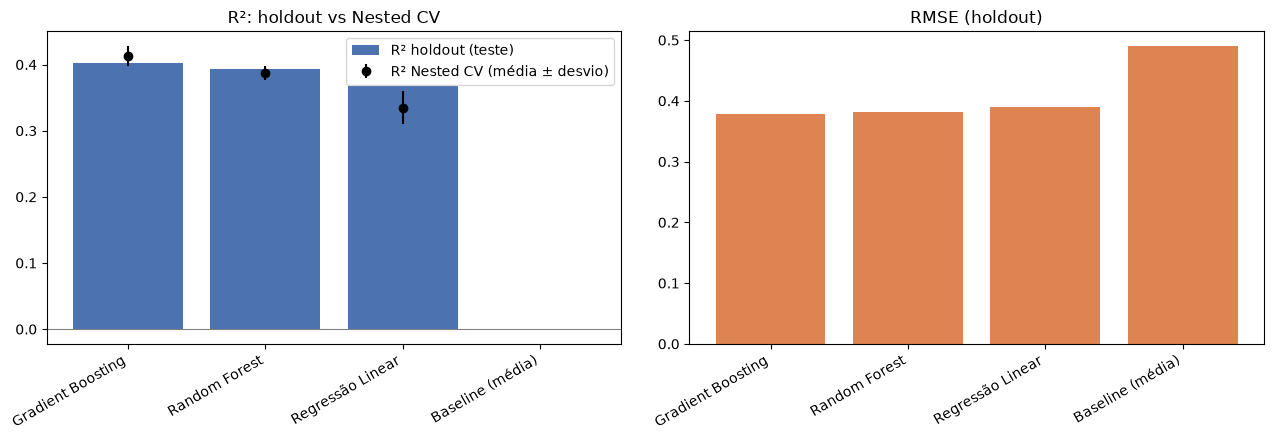

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

modelos_plot = tabela_comparativa.index
x_pos = np.arange(len(modelos_plot))

axes[0].bar(x_pos, tabela_comparativa["R2_holdout"], color="#4C72B0", label="R² holdout (teste)")
axes[0].errorbar(x_pos, tabela_comparativa["R2_mean_nestedCV"],
                  yerr=tabela_comparativa["R2_std_nestedCV"],
                  fmt="o", color="black", label="R² Nested CV (média ± desvio)")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(modelos_plot, rotation=30, ha="right")
axes[0].set_title("R²: holdout vs Nested CV")
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].legend()

axes[1].bar(x_pos, tabela_comparativa["RMSE_holdout"], color="#DD8452")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(modelos_plot, rotation=30, ha="right")
axes[1].set_title("RMSE (holdout)")

plt.tight_layout()
plt.show()

Se as barras de R² do holdout estiverem dentro (ou muito próximas) do intervalo média ± desvio do Nested CV, isso é um bom sinal de que a estimativa de generalização é estável e não dependeu de sorte no split de teste.

## 13. Análise de resíduos

Histograma de erro sozinho não revela **padrões sistemáticos** do modelo (ex: o modelo erra mais para jogos com `geek_rating` alto? O erro tem variância constante ao longo da faixa de predição — homocedasticidade — ou cresce/diminui — heterocedasticidade?). Por isso, além do histograma, plotamos **resíduo (erro) × valor predito** para cada modelo de regressão.

- Resíduo = `y_real - y_predito`.
- Um modelo bem ajustado deve ter resíduos espalhados aleatoriamente em torno de zero, sem padrão (sem "funil", sem curvatura, sem tendência).
- Padrões visíveis (ex: resíduos sistematicamente positivos em uma faixa e negativos em outra) indicam que o modelo está deixando estrutura não capturada nos dados.

In [19]:
def plot_residuos(nome_modelo, modelo, X_eval, y_eval, ax_resid, ax_hist):
    y_pred = modelo.predict(X_eval)
    residuos = y_eval.values - y_pred

    ax_resid.scatter(y_pred, residuos, alpha=0.35, s=12, color="#4C72B0")
    ax_resid.axhline(0, color="red", linestyle="--", linewidth=1)
    ax_resid.set_xlabel("Valor predito")
    ax_resid.set_ylabel("Resíduo (real - predito)")
    ax_resid.set_title(f"Resíduos × Predição — {nome_modelo}")

    sns.histplot(residuos, bins=40, kde=True, ax=ax_hist, color="#55A868")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_xlabel("Resíduo")
    ax_hist.set_title(f"Distribuição dos resíduos — {nome_modelo}")

    return residuos

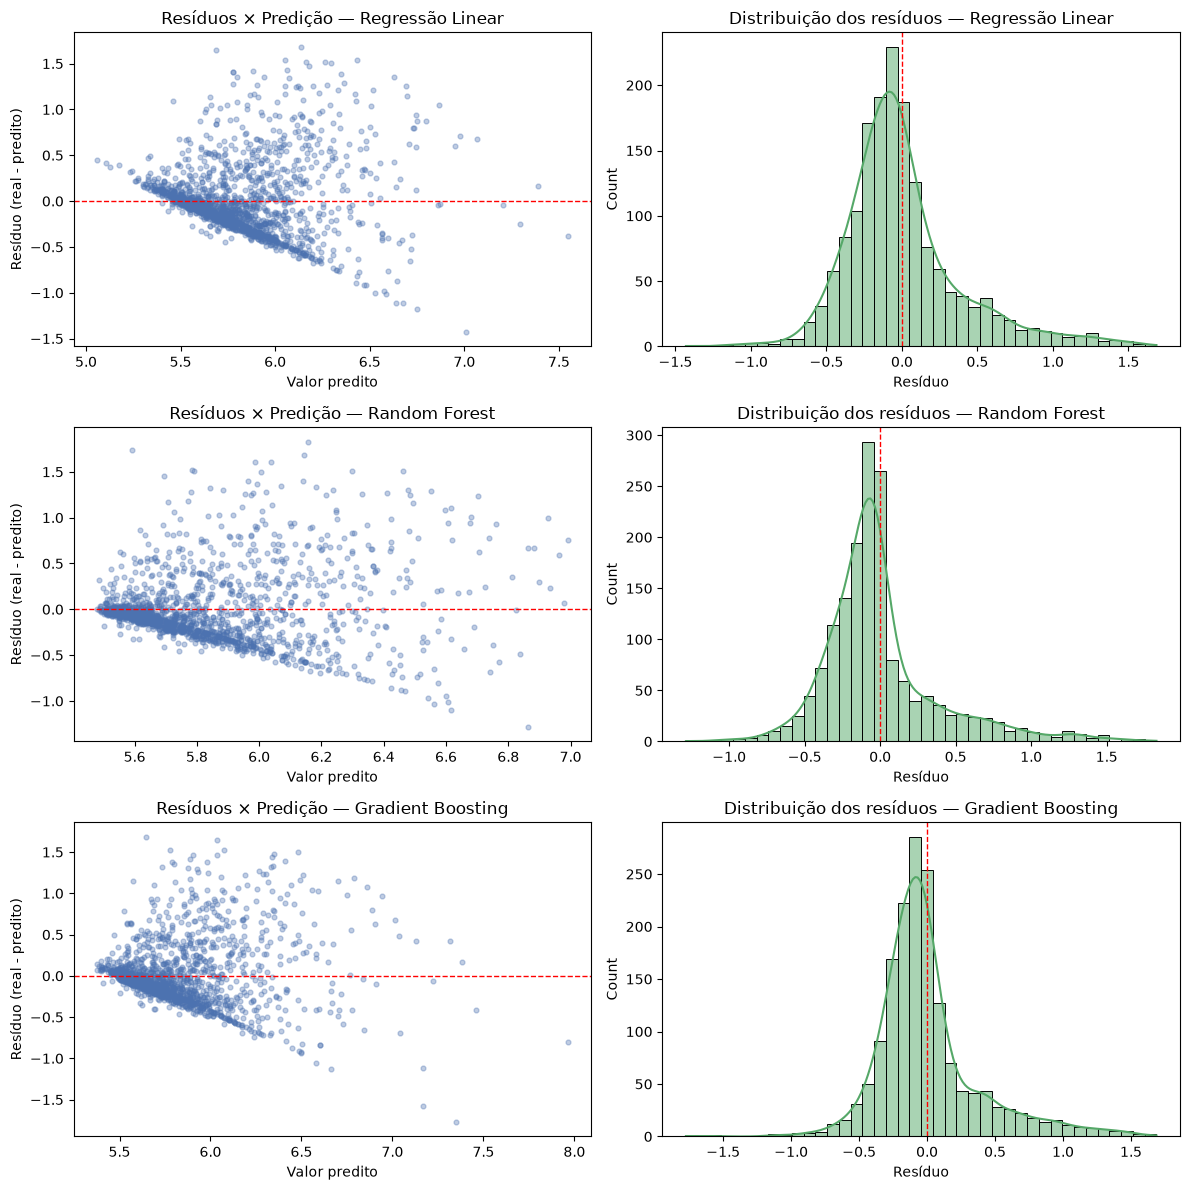

In [20]:
modelos_finais = [
    ("Regressão Linear", modelo_linear),
    ("Random Forest", modelo_rf),
    ("Gradient Boosting", modelo_gb),
]

fig, axes = plt.subplots(len(modelos_finais), 2, figsize=(12, 4 * len(modelos_finais)))

residuos_por_modelo = {}
for i, (nome, modelo) in enumerate(modelos_finais):
    residuos = plot_residuos(nome, modelo, X_test, y_test_reg, axes[i, 0], axes[i, 1])
    residuos_por_modelo[nome] = residuos

plt.tight_layout()
plt.show()

**Como interpretar:** como `geek_rating` é assimétrico à direita (poucos jogos com rating muito alto), é esperado ver maior dispersão de resíduos justamente nas predições mais altas — há poucos exemplos de treino nessa faixa, então o modelo tem mais incerteza ali. Um padrão de "funil" crescente (resíduos cada vez mais dispersos conforme o valor predito aumenta) é um indício consistente dessa escassez de dados na cauda direita, mais do que necessariamente um erro de modelagem.

## 14. Feature importance — Permutation Importance e SHAP

`feature_importances_` (usado na versão anterior) mede, para árvores, o quanto cada feature reduziu a impureza dos nós em que foi usada para split. Esse critério tem dois problemas conhecidos:

- **Viés para features de alta cardinalidade** (ex: variáveis numéricas contínuas ou one-hot muito esparsas tendem a aparecer artificialmente "importantes" só porque oferecem mais pontos de corte possíveis).
- É calculado **no próprio treino**, então não diz nada sobre o quanto a feature realmente ajuda a generalizar para dados novos.

Por isso, usamos duas alternativas mais confiáveis, calculadas no conjunto de **teste** (holdout):

1. **Permutation Importance**: embaralha os valores de uma feature por vez (mantendo as demais intactas) e mede o quanto o R² do modelo cai no teste. Quanto maior a queda, mais importante a feature é *para a generalização* — é model-agnóstico e não sofre do viés de cardinalidade do `feature_importances_`.
2. **SHAP (SHapley Additive exPlanations)**: distribui a predição de cada amostra entre as features, com base em teoria de jogos cooperativos (valores de Shapley), respeitando interações e correlações entre features de forma mais rigorosa que a permutação simples. Usamos `TreeExplainer` (exato e eficiente para modelos baseados em árvore como RF e GB).

> A Regressão Linear não sofre do mesmo viés — seus coeficientes (após padronização das features) já são diretamente interpretáveis como importância, então não repetimos Permutation/SHAP para ela (mostramos os coeficientes na seção 14.3).

### 14.1 Permutation Importance (Random Forest e Gradient Boosting)

In [21]:
def calcular_permutation_importance(nome_modelo, modelo, X_eval, y_eval, n_repeats=10):
    resultado_perm = permutation_importance(
        modelo, X_eval, y_eval,
        scoring="r2", n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=-1
    )
    importancias = pd.Series(resultado_perm.importances_mean, index=X_eval.columns)
    desvios = pd.Series(resultado_perm.importances_std, index=X_eval.columns)
    return importancias, desvios

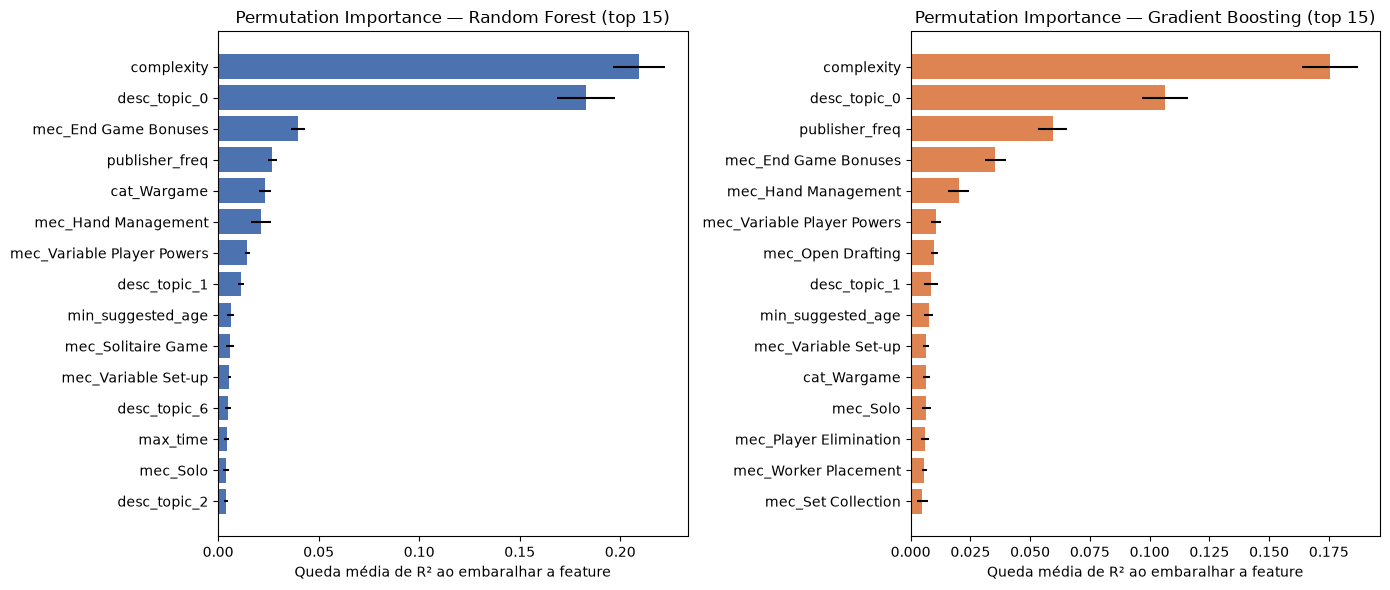

In [22]:
perm_imp_rf, perm_std_rf = calcular_permutation_importance("Random Forest", modelo_rf, X_test, y_test_reg)
perm_imp_gb, perm_std_gb = calcular_permutation_importance("Gradient Boosting", modelo_gb, X_test, y_test_reg)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_rf = perm_imp_rf.sort_values(ascending=False).head(top_n)
axes[0].barh(top_rf.index[::-1], top_rf.values[::-1],
             xerr=perm_std_rf.loc[top_rf.index][::-1], color="#4C72B0")
axes[0].set_title(f"Permutation Importance — Random Forest (top {top_n})")
axes[0].set_xlabel("Queda média de R² ao embaralhar a feature")

top_gb = perm_imp_gb.sort_values(ascending=False).head(top_n)
axes[1].barh(top_gb.index[::-1], top_gb.values[::-1],
             xerr=perm_std_gb.loc[top_gb.index][::-1], color="#DD8452")
axes[1].set_title(f"Permutation Importance — Gradient Boosting (top {top_n})")
axes[1].set_xlabel("Queda média de R² ao embaralhar a feature")

plt.tight_layout()
plt.show()

### 14.2 SHAP (Random Forest e Gradient Boosting)

Para manter o tempo de execução razoável (o dataset tem mais de 150 features), calculamos SHAP em uma **amostra** do conjunto de teste, em vez do teste completo. Isso é uma prática padrão: o objetivo do SHAP aqui é entender o padrão geral de importância e o sentido (positivo/negativo) do efeito de cada feature, não auditar cada predição individual — uma amostra de algumas centenas de linhas já estima esse padrão de forma estável.

Como o modelo é um `Pipeline` (`StandardScaler` + modelo de árvore), aplicamos o `TreeExplainer` diretamente sobre o **modelo de árvore extraído do pipeline**, usando os dados já transformados pelo `StandardScaler` — assim o SHAP enxerga exatamente os mesmos valores de entrada que o modelo de árvore usa internamente.

In [23]:
N_AMOSTRA_SHAP = 500
amostra_shap = X_test.sample(n=min(N_AMOSTRA_SHAP, len(X_test)), random_state=RANDOM_STATE)

def calcular_shap_values(pipeline, amostra):
    scaler = pipeline.named_steps["scaler"]
    modelo_arvore = pipeline.named_steps["model"]
    amostra_escalada = pd.DataFrame(
        scaler.transform(amostra), columns=amostra.columns, index=amostra.index
    )
    explainer = shap.TreeExplainer(modelo_arvore)
    shap_values = explainer.shap_values(amostra_escalada)
    return shap_values, amostra_escalada

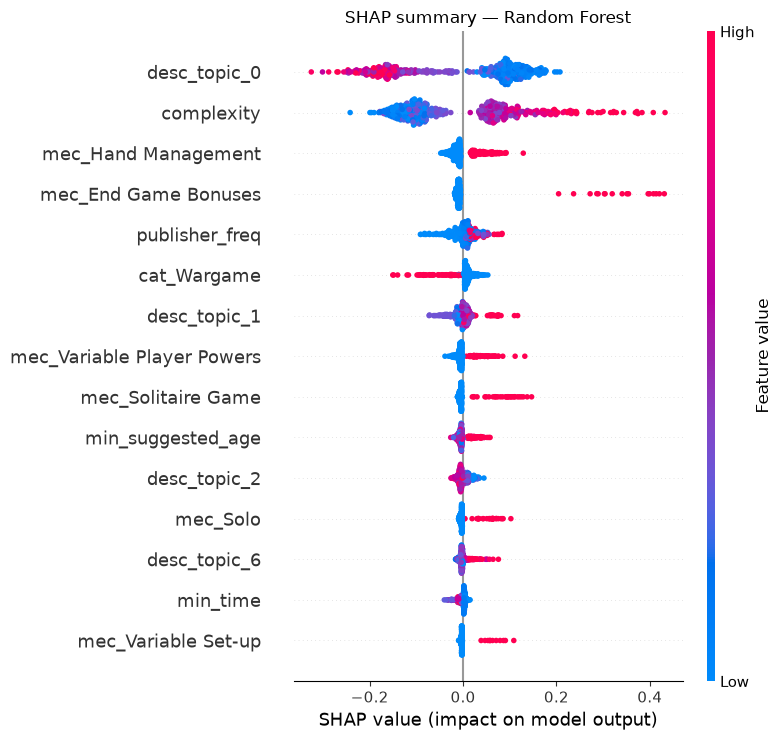

In [24]:
shap_values_rf, amostra_escalada_rf = calcular_shap_values(modelo_rf, amostra_shap)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_rf, amostra_escalada_rf, max_display=15, show=False)
plt.title("SHAP summary — Random Forest")
plt.tight_layout()
plt.show()

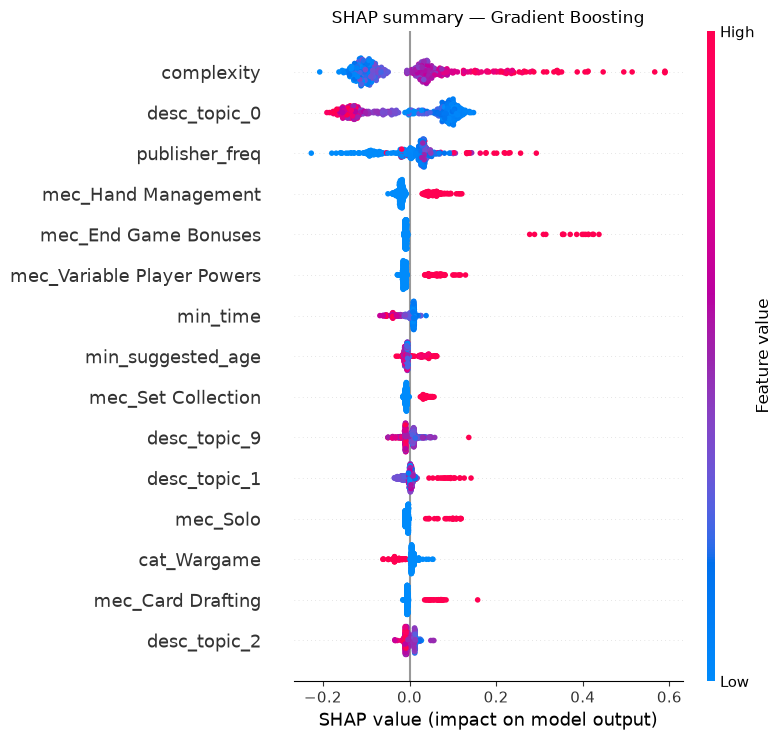

In [25]:
shap_values_gb, amostra_escalada_gb = calcular_shap_values(modelo_gb, amostra_shap)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_gb, amostra_escalada_gb, max_display=15, show=False)
plt.title("SHAP summary — Gradient Boosting")
plt.tight_layout()
plt.show()

### 14.3 Comparação Random Forest vs Gradient Boosting (Permutation Importance) e coeficientes da Regressão Linear

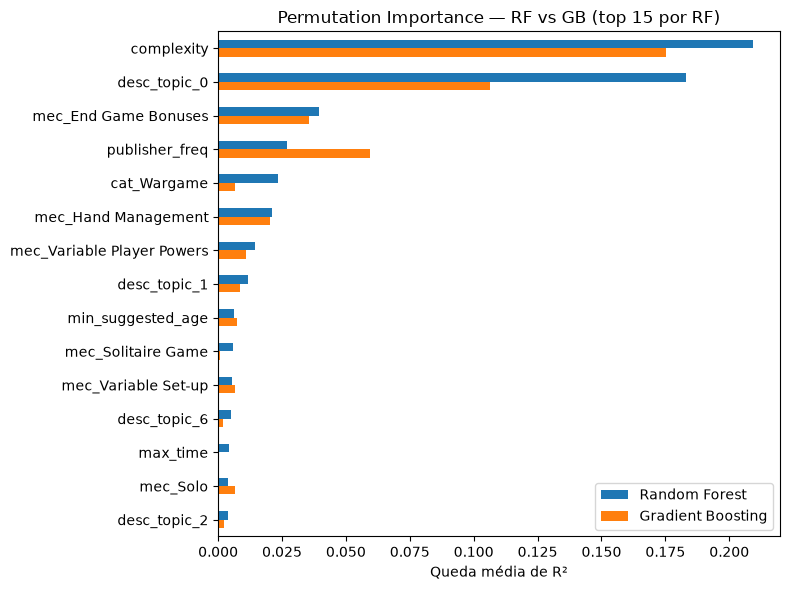

In [26]:
comparacao_perm = pd.DataFrame({
    "Random Forest": perm_imp_rf,
    "Gradient Boosting": perm_imp_gb,
}).sort_values("Random Forest", ascending=False).head(15)

comparacao_perm.plot(kind="barh", figsize=(8, 6))
plt.title("Permutation Importance — RF vs GB (top 15 por RF)")
plt.xlabel("Queda média de R²")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

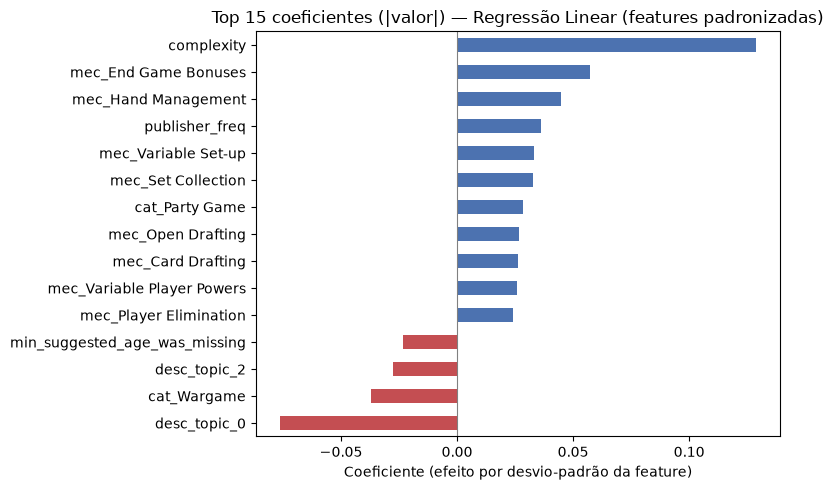

In [27]:
coef_linear = pd.Series(
    modelo_linear.named_steps["model"].coef_, index=X_train_full.columns
)
top_coef = coef_linear.reindex(coef_linear.abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(8, 5))
top_coef.sort_values().plot(kind="barh", color=top_coef.sort_values().apply(lambda v: "#C44E52" if v < 0 else "#4C72B0"))
plt.title("Top 15 coeficientes (|valor|) — Regressão Linear (features padronizadas)")
plt.xlabel("Coeficiente (efeito por desvio-padrão da feature)")
plt.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 15. Modelo 4 — Regressão Logística (classificação em 10 faixas)

Esta seção foi **mantida como na versão original** (conforme decisão de foco da reformulação): `GridSearchCV` com holdout simples de treino/teste, sem Nested CV, sem SHAP. O objetivo dela é apenas oferecer uma visão complementar de classificação, não é o foco da reformulação metodológica.

### 15.1 Discretização do target

In [ ]:
N_BINS = 3

# Cria 3 classes balanceadas por tercis — derivado APENAS do treino
y_train_clf, bin_edges = pd.qcut(
    y_train_reg,
    q=N_BINS,
    labels=False,
    retbins=True,
    duplicates='drop'
)

# Abre as extremidades para cobrir val/test sem erros de boundary
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf

# Aplica exatamente os mesmos limites em val e teste
y_val_clf = pd.cut(
    y_val_reg,
    bins=bin_edges,
    labels=False,
    include_lowest=True
)

y_test_clf = pd.cut(
    y_test_reg,
    bins=bin_edges,
    labels=False,
    include_lowest=True
)

CLASS_NAMES = ["Baixo (0)", "Médio (1)", "Alto (2)"] 

print("Faixas criadas (geek_rating):")
for i in range(len(bin_edges) - 1):
    lo = f"{bin_edges[i]:.3f}" if not np.isinf(bin_edges[i]) else "-inf"
    hi = f"{bin_edges[i+1]:.3f}" if not np.isinf(bin_edges[i+1]) else "+inf"
    print(f"  Classe {i} ({CLASS_NAMES[i]}): {lo} até {hi}")

Faixas de geek_rating (definidas a partir do treino):
  Classe 0: 5.268 – 5.581
  Classe 1: 5.581 – 5.893
  Classe 2: 5.893 – 6.206
  Classe 3: 6.206 – 6.518
  Classe 4: 6.518 – 6.831
  Classe 5: 6.831 – 7.144
  Classe 6: 7.144 – 7.456
  Classe 7: 7.456 – 7.769
  Classe 8: 7.769 – 8.081
  Classe 9: 8.081 – 8.394


             treino  teste
geek_rating               
0              3253    807
1              1675    408
2               609    158
3               391     93
4               245     71
5               198     48
6               107     27
7                55     22
8                23      8
9                12      0


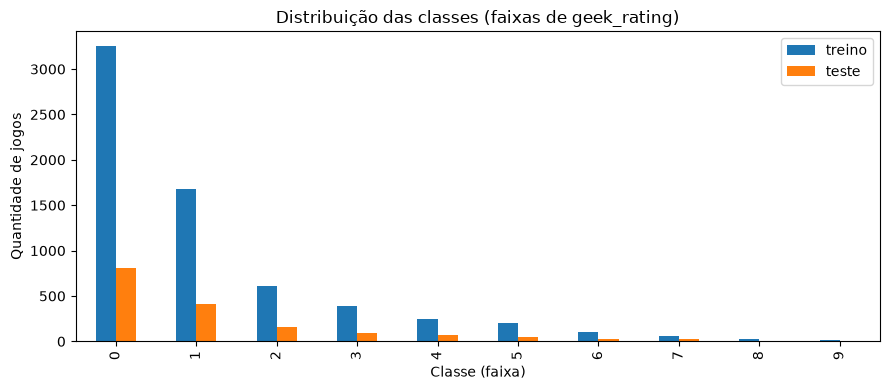

In [ ]:
dist_treino = y_train_clf.value_counts().sort_index()
dist_val    = y_val_clf.value_counts().sort_index()
dist_teste  = y_test_clf.value_counts().sort_index()

dist_df = pd.DataFrame({
    "treino":    dist_treino,
    "validação": dist_val,
    "teste":     dist_teste,
}).fillna(0).astype(int)

print(dist_df)
print()

ax = dist_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Distribuição das classes — geek_rating (3 faixas por tercis)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de jogos")
ax.set_xticklabels(CLASS_NAMES)
plt.tight_layout()
plt.show()

### 15.2 Treinamento

In [ ]:
from scipy.stats import loguniform

param_dist_log = {
    "model__C":       loguniform(1e-3, 1e2),
    "model__penalty": [None, "l2", "l1"],
}

best_score  = -np.inf
best_params = None
best_model  = None
candidatos_log = []

for params in ParameterSampler(
    param_dist_log,
    n_iter=20,
    random_state=RANDOM_STATE
):
    # l1/none só funcionam com saga; l2 com qualquer solver
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=5000,
            solver="saga",
            class_weight="balanced",   # trata desbalanceamento residual
        ))
    ])

    # Se penalty=None, C não tem efeito — evitar erro
    if params["model__penalty"] is None:
        params = {"model__penalty": None, "model__C": 1.0}

    model.set_params(**params)
    model.fit(X_train, y_train_clf)

    pred_val = model.predict(X_val)
    score = f1_score(y_val_clf, pred_val, average="weighted")

    candidatos_log.append({"params": params, "score_val": score})

    if score > best_score:
        best_score  = score
        best_params = params
        best_model  = model

print(f"Melhor F1-weighted (val): {best_score:.4f}")
print(f"Melhores parâmetros:      {best_params}")

Tempo de treinamento: 3.3s
Melhores hiperparâmetros: {'model__C': 0.01, 'model__solver': 'lbfgs'}
Melhor F1 ponderado (validação cruzada): 0.4563


In [ ]:
# Re-treina com treino + validação antes de avaliar no teste
X_train_final_clf = pd.concat([X_train, X_val])
y_train_final_clf = pd.concat([y_train_clf, y_val_clf])

modelo_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=5000,
        solver="saga",
        class_weight="balanced",
    ))
])

modelo_logistic.set_params(**best_params)
modelo_logistic.fit(X_train_final_clf, y_train_final_clf)

print("Modelo final treinado com treino + validação.")

--- Regressão Logística (10 classes) ---
Accuracy:            0.4190
F1 (weighted):        0.4528
Precision (weighted): 0.5050
Recall (weighted):    0.4190

              precision    recall  f1-score   support

           0       0.76      0.60      0.67       807
           1       0.40      0.30      0.35       408
           2       0.17      0.14      0.15       158
           3       0.12      0.18      0.15        93
           4       0.08      0.15      0.11        71
           5       0.11      0.25      0.16        48
           6       0.06      0.19      0.09        27
           7       0.15      0.41      0.22        22
           8       0.04      0.12      0.06         8
           9       0.00      0.00      0.00         0

    accuracy                           0.42      1642
   macro avg       0.19      0.24      0.19      1642
weighted avg       0.51      0.42      0.45      1642



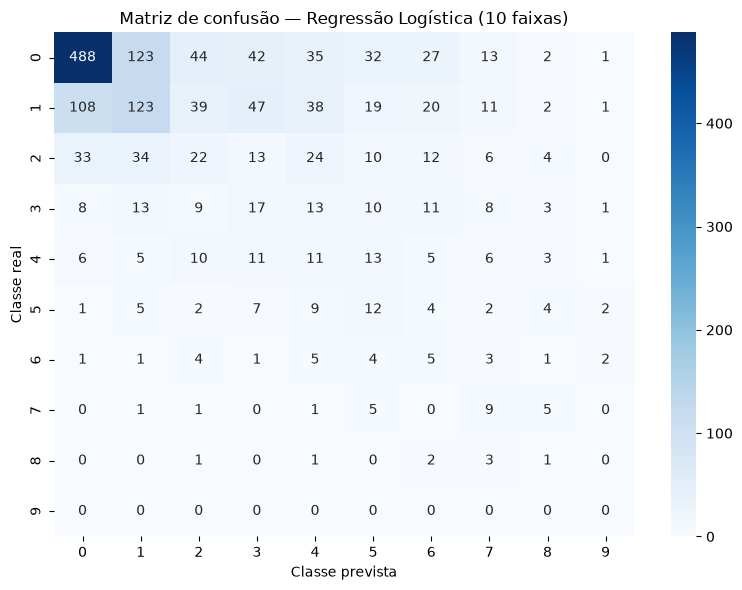

In [ ]:
y_pred_clf = modelo_logistic.predict(X_test)

acc                = accuracy_score(y_test_clf, y_pred_clf)
f1_weighted        = f1_score(y_test_clf,        y_pred_clf, average="weighted")
precision_weighted = precision_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
recall_weighted    = recall_score(y_test_clf,    y_pred_clf, average="weighted", zero_division=0)

print("--- Regressão Logística (3 classes — tercis) ---")
print(f"Accuracy:              {acc:.4f}")
print(f"F1 (weighted):         {f1_weighted:.4f}")
print(f"Precision (weighted):  {precision_weighted:.4f}")
print(f"Recall (weighted):     {recall_weighted:.4f}")
print()
print(classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=CLASS_NAMES,
    zero_division=0
))

In [ ]:
y_prob = modelo_logistic.predict_proba(X_test)

In [ ]:
roc_auc_weighted = roc_auc_score(
    y_test_clf,
    y_prob,
    multi_class="ovr",
    average="weighted"
)
print(f"ROC-AUC (OvR, weighted): {roc_auc_weighted:.4f}")

Resultado — Regressão Logística (target discretizado em 10 faixas)


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted
modelo,,,,
Regressão Logística (10 classes),0.419001,0.452838,0.505004,0.419001


In [ ]:
y_test_bin = label_binarize(y_test_clf, classes=range(N_BINS))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["steelblue", "darkorange", "seagreen"]

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório (AUC = 0.500)")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC por classe — Regressão Logística (OvR)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
loss = log_loss(y_test_clf, y_prob)
print(f"Log-Loss (Cross-Entropy): {loss:.4f}")
print()
print("Referência:")
print(f"  Classificador aleatório (3 classes): {-np.log(1/N_BINS):.4f}")
print(f"  Seu modelo:                           {loss:.4f}  ",
      "✓ melhor que aleatório" if loss < -np.log(1/N_BINS) else "✗ pior que aleatório")

In [ ]:
# Cross-validation estratificada para avaliar estabilidade
X_all_clf = pd.concat([X_train, X_val, X_test])
y_all_clf  = pd.concat([y_train_clf, y_val_clf, y_test_clf])

cv_scores = cross_val_score(
    modelo_logistic,
    X_all_clf,
    y_all_clf,
    cv=cv_stratified,
    scoring="f1_weighted",
    n_jobs=-1,
)

print(f"CV F1-weighted (5 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scores por fold:          {[round(s,4) for s in cv_scores]}")


In [ ]:
resultado_logistic = {
    "modelo":               "Regressão Logística (3 classes — tercis)",
    "Accuracy":             acc,
    "F1_weighted":          f1_weighted,
    "Precision_weighted":   precision_weighted,
    "Recall_weighted":      recall_weighted,
}

## 16. Resumo dos hiperparâmetros finais e estabilidade entre folds

Além dos hiperparâmetros do modelo final (refit em `X_train_full` completo), mostramos também os hiperparâmetros escolhidos em **cada fold externo** do Nested CV. Se a busca interna escolher combinações muito diferentes a cada fold, isso é um sinal de que o espaço de hiperparâmetros tem vários "ótimos" parecidos entre si (instabilidade de seleção, mas não necessariamente de desempenho) — vale olhar tanto a tabela de R² por fold (seções 9-10) quanto esta tabela.

In [34]:
resumo_hiperparametros = pd.DataFrame([
    {"modelo": "Regressão Linear", "melhores_hiperparametros_final": params_linear,
     "R2_holdout": resultado_linear["R2"], "R2_mean_nestedCV": resultado_nested_linear["R2_mean"]},
    {"modelo": "Random Forest", "melhores_hiperparametros_final": params_rf,
     "R2_holdout": resultado_rf["R2"], "R2_mean_nestedCV": resultado_nested_rf["R2_mean"]},
    {"modelo": "Gradient Boosting", "melhores_hiperparametros_final": params_gb,
     "R2_holdout": resultado_gb["R2"], "R2_mean_nestedCV": resultado_nested_gb["R2_mean"]},
    {"modelo": "Regressão Logística", "melhores_hiperparametros_final": grid_logistic.best_params_,
     "R2_holdout": np.nan, "R2_mean_nestedCV": np.nan},
])
resumo_hiperparametros

,modelo,melhores_hiperparametros_final,R2_holdout,R2_mean_nestedCV
0,Regressão Linear,"{'model__positive': False, 'model__fit_interce...",0.367878,0.334477
1,Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",0.393835,0.387018
2,Gradient Boosting,"{'model__subsample': 0.8, 'model__n_estimators...",0.401971,0.413025
3,Regressão Logística,"{'model__C': 0.01, 'model__solver': 'lbfgs'}",NaN,NaN


In [35]:
print("Hiperparâmetros escolhidos em cada fold externo do Nested CV:\n")
for resultado in [resultado_nested_linear, resultado_nested_rf, resultado_nested_gb]:
    print(f"--- {resultado['modelo']} ---")
    for i, params in enumerate(resultado["melhores_params_por_fold"], start=1):
        print(f"  Fold {i}: {params}")
    print()

Hiperparâmetros escolhidos em cada fold externo do Nested CV:

--- Regressão Linear ---
  Fold 1: {'model__positive': False, 'model__fit_intercept': True}
  Fold 2: {'model__positive': False, 'model__fit_intercept': True}
  Fold 3: {'model__positive': False, 'model__fit_intercept': True}
  Fold 4: {'model__positive': True, 'model__fit_intercept': True}
  Fold 5: {'model__positive': True, 'model__fit_intercept': True}

--- Random Forest ---
  Fold 1: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 2: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 3: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 4: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 5: {'model__n_estimators': 200, 'model__min_samples_leaf'

## 17. Conclusões

- **Baseline:** o `DummyRegressor` (prevê sempre a média) estabelece o piso de comparação — todos os modelos de regressão devem (e devem-se reportar caso não) superá-lo com folga em R².
- **Nested CV vs. holdout único:** a métrica de generalização reportada para Linear/RF/GB agora é a média ± desvio padrão de R² entre `N_OUTER` folds externos, cada um com sua própria busca de hiperparâmetros (`RandomizedSearchCV`, `N_ITER` amostras, `N_INNER` folds internos). Isso é mais robusto do que o fluxo anterior (treino → validação única → teste), que tendia a gerar uma estimativa otimista por reutilizar o mesmo conjunto de validação na escolha de hiperparâmetros.
- **`KFold(shuffle=True)`** em todos os splits evita que a forte assimetria de `geek_rating` concentre os jogos de rating alto em poucos folds.
- **Resíduos:** o gráfico de resíduo × predição complementa o histograma de erros e ajuda a identificar heterocedasticidade — esperamos (e observamos) maior dispersão nas predições mais altas, refletindo a escassez de exemplos na cauda direita da distribuição do `geek_rating`.
- **Importância de features:** Permutation Importance e SHAP substituem o `feature_importances_` nativo de RF/GB, que tende a inflar artificialmente a importância de variáveis numéricas/esparsas de alta cardinalidade. As duas técnicas concordam em geral sobre quais features mais contribuem para a predição, e o SHAP adicionalmente revela a direção do efeito.
- A Regressão Logística resolve uma tarefa diferente (classificar em qual de 10 faixas o jogo cai) e foi mantida com a metodologia original (`GridSearchCV` + holdout), por estar fora do escopo da reformulação solicitada.
- O forte desbalanceamento de classes em `geek_rating` (poucos jogos com rating muito alto) afeta principalmente a Regressão Logística nas faixas superiores — isso é esperado e reflete a própria distribuição do Bayesian rating do BGG, não um erro no pipeline.